In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kendalltau

In [2]:
FONT_SIZE = 12
FONT_WEIGHT = 'bold'

In [111]:
search_space = 'nasbench201'
# device = 'edgegpu, edgetpu, eyeriss, fpga, pixel3, raspi4'
device = 'raspi4'

In [112]:
device_test = pd.read_csv(f'history/{device}test_results.csv')
# device_test['Predicted Accuracy'] = [float(x.strip('[]')) for x in device_test['Predicted Accuracy']]
device_test['Predicted Latency'] = [float(x.strip('[]')) for x in device_test['Predicted Latency']]
device_test.head()

,Batch,Original Text,True Latency,Predicted Latency
0,0,"|1_Convolution:(num_filters=16, kernel_size=3)...",10.004124,10.707603
1,1,"|1_Convolution:(num_filters=16, kernel_size=3)...",28.760392,27.505714
2,2,"|1_Convolution:(num_filters=16, kernel_size=3)...",57.171540,52.876663
3,3,"|1_Convolution:(num_filters=16, kernel_size=3)...",20.466297,17.120632
4,4,"|1_Convolution:(num_filters=16, kernel_size=3)...",30.304249,30.398209


Latency Pearson: 0.9762
Latency Kendall Tau: 0.8659
0.011283500061836 81.79247941996437
-3.0767057 82.243935


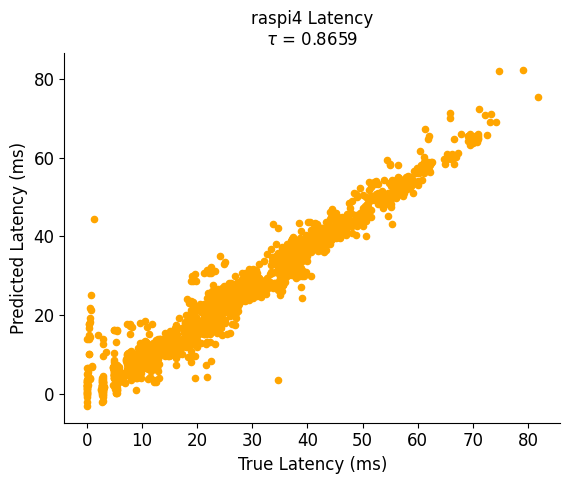

In [113]:
correlation = np.corrcoef(device_test['True Latency'], device_test['Predicted Latency'])[0, 1]
print(f'Latency Pearson: {correlation:.4f}')
tau, p_value = kendalltau(device_test['True Latency'], device_test['Predicted Latency'])
print(f'Latency Kendall Tau: {tau:.4f}')

print(device_test['True Latency'].min(), device_test['True Latency'].max())
print(device_test['Predicted Latency'].min(), device_test['Predicted Latency'].max())

fig, ax = plt.subplots()
ax.scatter(device_test['True Latency'], device_test['Predicted Latency'], s=20, c='orange')
ax.set_xlabel('True Latency (ms)', fontsize=FONT_SIZE)
ax.set_ylabel('Predicted Latency (ms)', fontsize=FONT_SIZE)
ax.set_title(f'{device} Latency\n$\\tau$ = {tau:.4f}', fontsize=FONT_SIZE)
ax.tick_params(axis='both', which='major', labelsize=12)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig(f'plots/{search_space}_{device}.png', dpi=300, bbox_inches='tight')
plt.show()

End with the code above...

In [89]:
def pareto_optimality(accuracy, latency):
    vals = np.column_stack((accuracy, latency))
    population_size = vals.shape[0]
    pareto_front = np.ones(population_size, dtype=bool)

    for i in range(population_size):
        for j in range(population_size):
            if all(vals[j] >= vals[i]) and any(vals[j] > vals[i]):
                pareto_front[i] = 0
                break

    pareto_indices = np.arange(population_size)[pareto_front]
    pareto_front = vals[pareto_indices]

    return pareto_indices, pareto_front

In [90]:
search_space = 'nasbench201'
device = 'edgegpu'

In [91]:
device_test = pd.read_csv(f'history/{search_space}/{device}_test_results.csv')
device_test['Predicted Accuracy'] = [float(x.strip('[]')) for x in device_test['Predicted Accuracy']]
device_test['Predicted Latency'] = [float(x.strip('[]')) for x in device_test['Predicted Latency']]
device_test.head()

,Batch,Original Text,True Accuracy,True Latency,Predicted Accuracy,Predicted Latency
0,0,"|1_Convolution:(num_filters=16, kernel_size=3)...",22.733333,3.744855,23.766106,3.375252
1,1,"|1_Convolution:(num_filters=16, kernel_size=3)...",19.366667,6.244216,19.492027,4.786514
2,2,"|1_Convolution:(num_filters=16, kernel_size=3)...",22.266667,6.427178,23.634972,4.900172
3,3,"|1_Convolution:(num_filters=16, kernel_size=3)...",16.033333,5.880632,16.634245,4.554001
4,4,"|1_Convolution:(num_filters=16, kernel_size=3)...",22.600000,7.029600,24.060713,5.491496


Accuracy

0.6538601978323595
0.4606693199612979 0.0


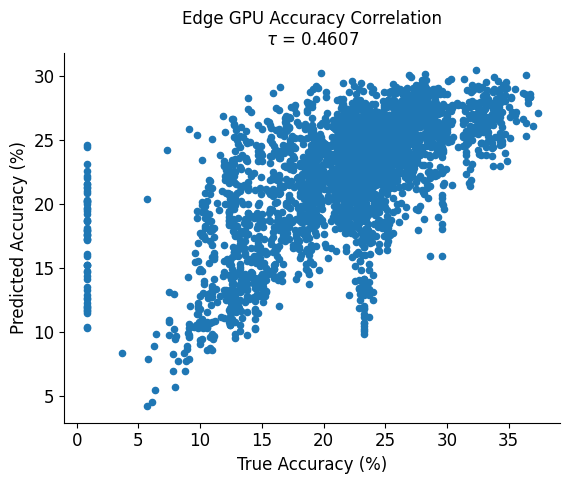

In [92]:
correlation = np.corrcoef(device_test['True Accuracy'], device_test['Predicted Accuracy'])[0, 1]
print(correlation)
tau, p_value = kendalltau(device_test['True Accuracy'], device_test['Predicted Accuracy'])
print(tau, p_value)


fig, ax = plt.subplots()
ax.scatter(device_test['True Accuracy'], device_test['Predicted Accuracy'], s=20)
ax.set_xlabel('True Accuracy (%)', fontsize=FONT_SIZE)
ax.set_ylabel('Predicted Accuracy (%)', fontsize=FONT_SIZE)
ax.set_title(f'Edge GPU Accuracy Correlation\n$\\tau$ = {tau:.4f}', fontsize=FONT_SIZE)
ax.tick_params(axis='both', which='major', labelsize=12)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

Latency

Latency Pearson: 0.9508646835993523
Latency Kendall Tau: 0.8433965426041519
0.5405187606811523 9.865565299987791
0.8206306 6.2818513


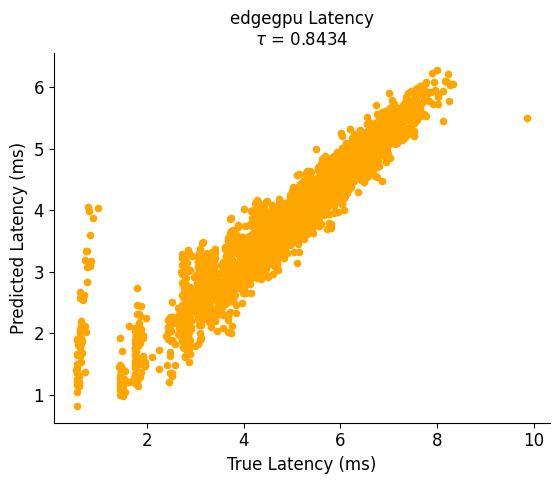

In [93]:
correlation = np.corrcoef(device_test['True Latency'], device_test['Predicted Latency'])[0, 1]
print(f'Latency Pearson: {correlation}')
tau, p_value = kendalltau(device_test['True Latency'], device_test['Predicted Latency'])
print(f'Latency Kendall Tau: {tau}')

print(device_test['True Latency'].min(), device_test['True Latency'].max())
print(device_test['Predicted Latency'].min(), device_test['Predicted Latency'].max())

fig, ax = plt.subplots()
ax.scatter(device_test['True Latency'], device_test['Predicted Latency'], s=20, c='orange')
ax.set_xlabel('True Latency (ms)', fontsize=FONT_SIZE)
ax.set_ylabel('Predicted Latency (ms)', fontsize=FONT_SIZE)
ax.set_title(f'{device} Latency\n$\\tau$ = {tau:.4f}', fontsize=FONT_SIZE)
ax.tick_params(axis='both', which='major', labelsize=12)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig(f'plots/{search_space}_{device}.png', dpi=300, bbox_inches='tight')
plt.show()

# Edge GPU Output

Training Pattern

In [94]:
# edgegpu_train = pd.read_csv('history/nasbench201/edgegpu_train_history.csv')
edgegpu_train = pd.read_csv('history/fbnet/edge_gpu_train_history.csv')

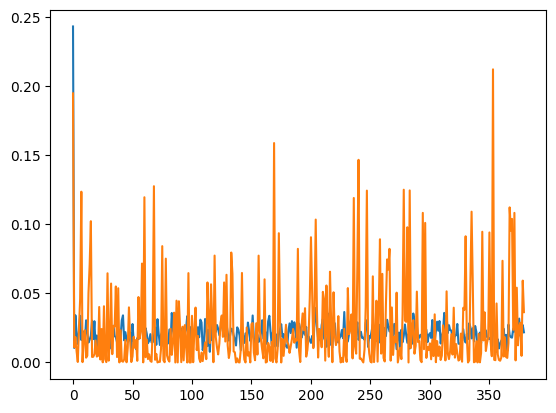

In [95]:
fig, ax = plt.subplots()
ax.plot(edgegpu_train['Train_loss'])
ax.plot(edgegpu_train['Val_loss'])
plt.show()

Test Results

In [96]:
# edgegpu_test = pd.read_csv('history/nasbench201/edgegpu_test_results.csv')
edgegpu_test = pd.read_csv('history/fbnet/edge_gpu_test_results.csv')
# edgegpu_test['Predicted Accuracy'] = [float(x.strip('[]')) for x in edgegpu_test['Predicted Accuracy']]
edgegpu_test['Predicted Latency'] = [float(x.strip('[]')) for x in edgegpu_test['Predicted Latency']]
edgegpu_test.head()

,Batch,Original Text,True Latency,Predicted Latency
0,0,"|1_Convolution:(num_filters=16, kernel_size=3)...",20.439497,20.828041
1,1,"|1_Convolution:(num_filters=16, kernel_size=3)...",23.140096,20.830670
2,2,"|1_Convolution:(num_filters=16, kernel_size=3)...",21.482320,20.802578
3,3,"|1_Convolution:(num_filters=16, kernel_size=3)...",20.141828,20.793201
4,4,"|1_Convolution:(num_filters=16, kernel_size=3)...",23.838904,20.810352


Accuracy - Don't run for FBNet

In [97]:
correlation = np.corrcoef(edgegpu_test['True Accuracy'], edgegpu_test['Predicted Accuracy'])[0, 1]
print(correlation)
tau, p_value = kendalltau(edgegpu_test['True Accuracy'], edgegpu_test['Predicted Accuracy'])
print(tau, p_value)


fig, ax = plt.subplots()
ax.scatter(edgegpu_test['True Accuracy'], edgegpu_test['Predicted Accuracy'], s=20)
ax.set_xlabel('True Accuracy (%)', fontsize=FONT_SIZE)
ax.set_ylabel('Predicted Accuracy (%)', fontsize=FONT_SIZE)
ax.set_title(f'Edge GPU Accuracy Correlation\n$\\tau$ = {tau:.4f}', fontsize=FONT_SIZE)
ax.tick_params(axis='both', which='major', labelsize=12)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

KeyError: 'True Accuracy'

Latency

Latency Pearson: -0.007930485259087156
Latency Kendall Tau: -0.0050988367669845235
16.026021242141724 25.892554759979248
20.755781 20.87184


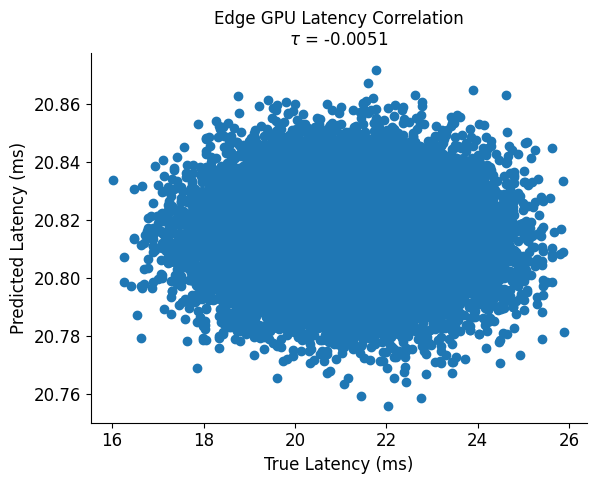

In [ ]:
correlation = np.corrcoef(edgegpu_test['True Latency'], edgegpu_test['Predicted Latency'])[0, 1]
print(f'Latency Pearson: {correlation}')
tau, p_value = kendalltau(edgegpu_test['True Latency'], edgegpu_test['Predicted Latency'])
print(f'Latency Kendall Tau: {tau}')

print(edgegpu_test['True Latency'].min(), edgegpu_test['True Latency'].max())
print(edgegpu_test['Predicted Latency'].min(), edgegpu_test['Predicted Latency'].max())

fig, ax = plt.subplots()
ax.scatter(edgegpu_test['True Latency'], edgegpu_test['Predicted Latency'])
ax.set_xlabel('True Latency (ms)', fontsize=FONT_SIZE)
ax.set_ylabel('Predicted Latency (ms)', fontsize=FONT_SIZE)
ax.set_title(f'Edge GPU Latency\n$\\tau$ = {tau:.4f}', fontsize=FONT_SIZE)
ax.tick_params(axis='both', which='major', labelsize=12)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

Accuracy vs Latency

Latency Pearson: 0.4925092938906935
Latency Kendall Tau: 0.32995530447228444


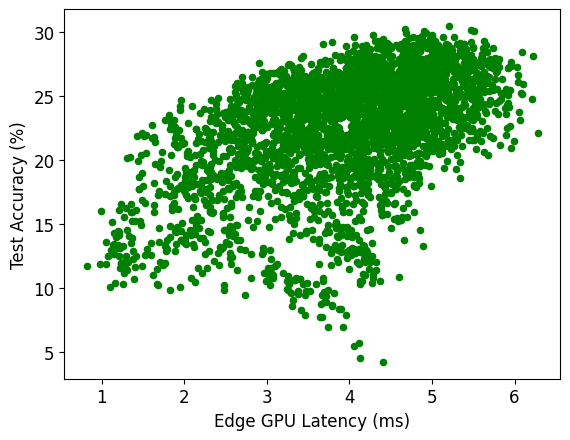

In [ ]:
pareto_indices, pareto_front = pareto_optimality(edgegpu_test['Predicted Latency'], edgegpu_test['Predicted Accuracy'])
correlation = np.corrcoef(edgegpu_test['Predicted Latency'], edgegpu_test['Predicted Accuracy'])[0, 1]
print(f'Latency Pearson: {correlation}')
tau, p_value = kendalltau(edgegpu_test['Predicted Latency'], edgegpu_test['Predicted Accuracy'])
print(f'Latency Kendall Tau: {tau}')

fig, ax = plt.subplots()
ax.scatter(edgegpu_test['Predicted Latency'], edgegpu_test['Predicted Accuracy'], s=20, c='green')
ax.set_ylabel('Test Accuracy (%)', fontsize=FONT_SIZE)
ax.set_xlabel('Edge GPU Latency (ms)', fontsize=FONT_SIZE)
# ax.set_title('Accuracy Correlation', fontsize=FONT_SIZE)
ax.tick_params(axis='both', which='major', labelsize=12)
plt.show()

# Edge TPU Output

Training Pattern

In [ ]:
edgetpu_train = pd.read_csv('history/nasbench201/edgetpu_train_history.csv')

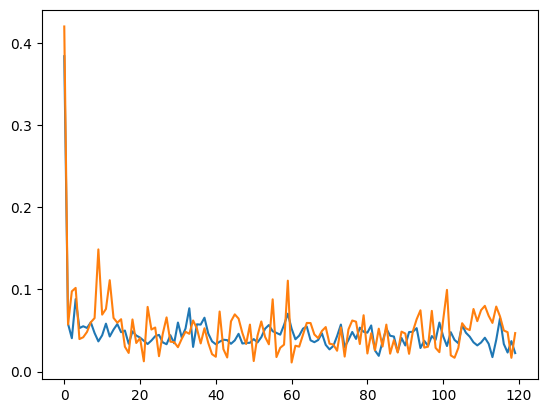

In [ ]:
fig, ax = plt.subplots()
ax.plot(edgetpu_train['Train_loss'])
ax.plot(edgetpu_train['Val_loss'])
plt.show()

Test Results

In [ ]:
edgetpu_test = pd.read_csv('history/nasbench201/edgetpu_test_results.csv')
edgetpu_test['Predicted Accuracy'] = [float(x.strip('[]')) for x in edgetpu_test['Predicted Accuracy']]
edgetpu_test['Predicted Latency'] = [float(x.strip('[]')) for x in edgetpu_test['Predicted Latency']]
edgetpu_test.head()

,Batch,Original Text,True Accuracy,True Latency,Predicted Accuracy,Predicted Latency
0,0,"|1_Convolution:(num_filters=16, kernel_size=3)...",22.733333,-1.000000,23.519852,-0.560472
1,1,"|1_Convolution:(num_filters=16, kernel_size=3)...",19.366667,1.173283,20.763483,1.295837
2,2,"|1_Convolution:(num_filters=16, kernel_size=3)...",22.266667,1.101941,21.568098,0.625600
3,3,"|1_Convolution:(num_filters=16, kernel_size=3)...",16.033333,1.158397,17.537035,1.321833
4,4,"|1_Convolution:(num_filters=16, kernel_size=3)...",22.600000,1.390146,22.182580,1.274514


Accuracy

0.6197882211093544
0.42732950151688665 1.066782763692917e-280


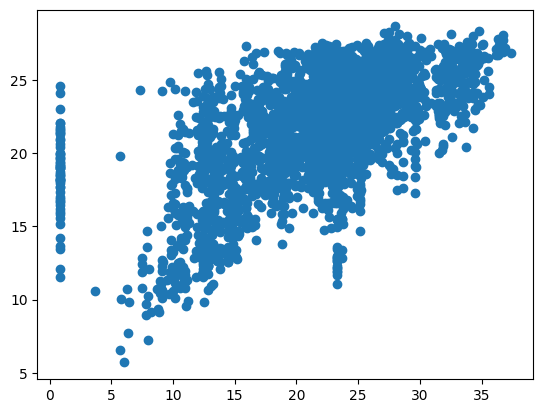

In [ ]:
correlation = np.corrcoef(edgetpu_test['True Accuracy'], edgetpu_test['Predicted Accuracy'])[0, 1]
print(correlation)
tau, p_value = kendalltau(edgetpu_test['True Accuracy'], edgetpu_test['Predicted Accuracy'])
print(tau, p_value)


fig, ax = plt.subplots()
ax.scatter(edgetpu_test['True Accuracy'], edgetpu_test['Predicted Accuracy'])

plt.show()

Latency

Latency Pearson: 0.6881288456688918
Latency Kendall Tau: 0.5833821786604817
-1.0 1.6628657900146209
-1.4645041 1.451515


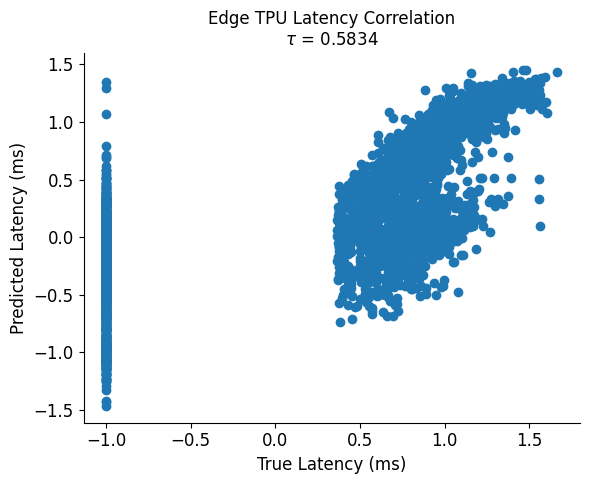

In [ ]:
correlation = np.corrcoef(edgetpu_test['True Latency'], edgetpu_test['Predicted Latency'])[0, 1]
print(f'Latency Pearson: {correlation}')
tau, p_value = kendalltau(edgetpu_test['True Latency'], edgetpu_test['Predicted Latency'])
print(f'Latency Kendall Tau: {tau}')

print(edgetpu_test['True Latency'].min(), edgetpu_test['True Latency'].max())
print(edgetpu_test['Predicted Latency'].min(), edgetpu_test['Predicted Latency'].max())

fig, ax = plt.subplots()
ax.scatter(edgetpu_test['True Latency'], edgetpu_test['Predicted Latency'])
ax.set_xlabel('True Latency (ms)', fontsize=FONT_SIZE)
ax.set_ylabel('Predicted Latency (ms)', fontsize=FONT_SIZE)
ax.set_title(f'Edge TPU Latency Correlation\n$\\tau$ = {tau:.4f}', fontsize=FONT_SIZE)
ax.tick_params(axis='both', which='major', labelsize=12)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

Accuracy vs Latency

Latency Pearson: 0.10078642563060156
Latency Kendall Tau: 0.09178675375913009


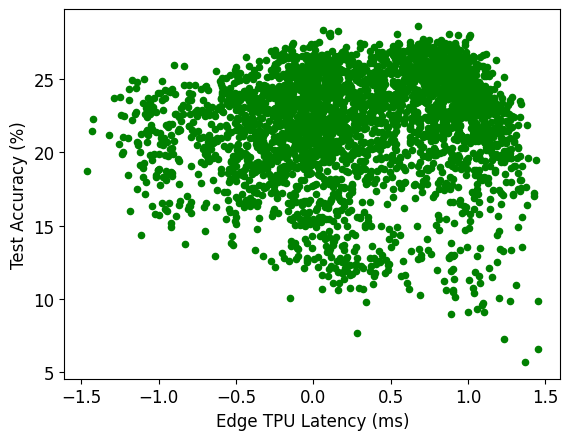

In [ ]:
pareto_indices, pareto_front = pareto_optimality(edgetpu_test['Predicted Latency'], edgetpu_test['Predicted Accuracy'])
correlation = np.corrcoef(edgetpu_test['Predicted Latency'], edgetpu_test['Predicted Accuracy'])[0, 1]
print(f'Latency Pearson: {correlation}')
tau, p_value = kendalltau(edgetpu_test['Predicted Latency'], edgetpu_test['Predicted Accuracy'])
print(f'Latency Kendall Tau: {tau}')

fig, ax = plt.subplots()
ax.scatter(edgetpu_test['Predicted Latency'], edgetpu_test['Predicted Accuracy'], s=20, c='green')
ax.set_ylabel('Test Accuracy (%)', fontsize=FONT_SIZE)
ax.set_xlabel('Edge TPU Latency (ms)', fontsize=FONT_SIZE)
ax.tick_params(axis='both', which='major', labelsize=12)
plt.show()

# Eyeriss Output

Training Pattern

In [ ]:
eyeriss_train = pd.read_csv('history/nasbench201/eyeriss_train_history.csv')

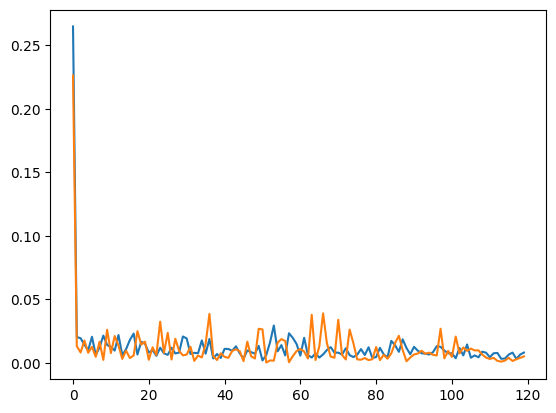

In [ ]:
fig, ax = plt.subplots()
ax.plot(eyeriss_train['Train_loss'])
ax.plot(eyeriss_train['Val_loss'])
plt.show()

Test Results

In [ ]:
eyeriss_test = pd.read_csv('history/nasbench201/eyeriss_test_results.csv')
eyeriss_test['Predicted Accuracy'] = [float(x.strip('[]')) for x in eyeriss_test['Predicted Accuracy']]
eyeriss_test['Predicted Latency'] = [float(x.strip('[]')) for x in eyeriss_test['Predicted Latency']]
eyeriss_test.head()

,Batch,Original Text,True Accuracy,True Latency,Predicted Accuracy,Predicted Latency
0,0,"|1_Convolution:(num_filters=16, kernel_size=3)...",22.733333,1.65184,24.160854,1.609683
1,1,"|1_Convolution:(num_filters=16, kernel_size=3)...",19.366667,1.95904,19.210300,1.995587
2,2,"|1_Convolution:(num_filters=16, kernel_size=3)...",22.266667,1.95904,23.432976,1.947703
3,3,"|1_Convolution:(num_filters=16, kernel_size=3)...",16.033333,1.95904,15.534019,1.976881
4,4,"|1_Convolution:(num_filters=16, kernel_size=3)...",22.600000,2.02048,26.542908,2.010331


Accuracy

0.6410903280310452
0.4498198729037026 0.0


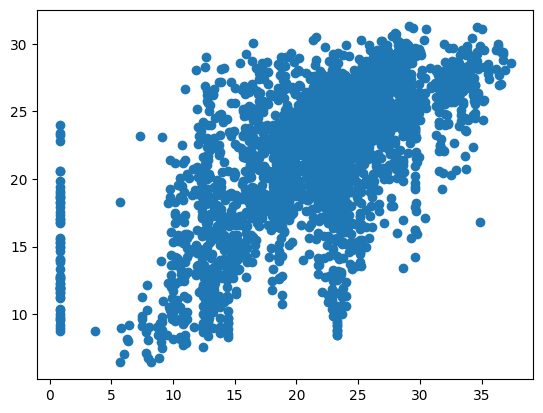

In [ ]:
correlation = np.corrcoef(eyeriss_test['True Accuracy'], eyeriss_test['Predicted Accuracy'])[0, 1]
print(correlation)
tau, p_value = kendalltau(eyeriss_test['True Accuracy'], eyeriss_test['Predicted Accuracy'])
print(tau, p_value)


fig, ax = plt.subplots()
ax.scatter(eyeriss_test['True Accuracy'], eyeriss_test['Predicted Accuracy'])
plt.show()

Latency

Latency Pearson: 0.9952484477738847
Latency Kendall Tau: 0.9350526452399425
0.4230400000000001 2.63488
0.3731086 2.6580172


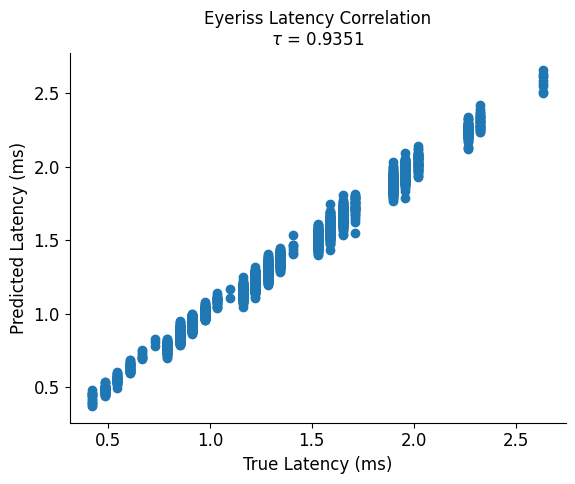

In [ ]:
correlation = np.corrcoef(eyeriss_test['True Latency'], eyeriss_test['Predicted Latency'])[0, 1]
print(f'Latency Pearson: {correlation}')
tau, p_value = kendalltau(eyeriss_test['True Latency'], eyeriss_test['Predicted Latency'])
print(f'Latency Kendall Tau: {tau}')

print(eyeriss_test['True Latency'].min(), eyeriss_test['True Latency'].max())
print(eyeriss_test['Predicted Latency'].min(), eyeriss_test['Predicted Latency'].max())

fig, ax = plt.subplots()
ax.scatter(eyeriss_test['True Latency'], eyeriss_test['Predicted Latency'])
ax.set_xlabel('True Latency (ms)', fontsize=FONT_SIZE)
ax.set_ylabel('Predicted Latency (ms)', fontsize=FONT_SIZE)
ax.set_title(f'Eyeriss Latency Correlation\n$\\tau$ = {tau:.4f}', fontsize=FONT_SIZE)
ax.tick_params(axis='both', which='major', labelsize=12)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

Accuracy vs Latency

Latency Pearson: 0.16136953040365398
Latency Kendall Tau: 0.11205555300042662


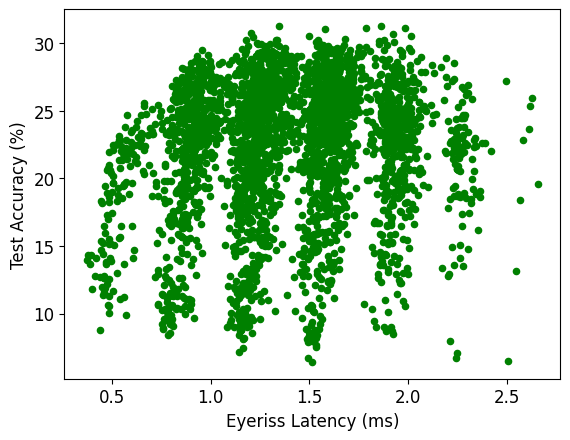

In [ ]:
pareto_indices, pareto_front = pareto_optimality(eyeriss_test['Predicted Latency'], eyeriss_test['Predicted Accuracy'])
correlation = np.corrcoef(eyeriss_test['Predicted Latency'], eyeriss_test['Predicted Accuracy'])[0, 1]
print(f'Latency Pearson: {correlation}')
tau, p_value = kendalltau(eyeriss_test['Predicted Latency'], eyeriss_test['Predicted Accuracy'])
print(f'Latency Kendall Tau: {tau}')

fig, ax = plt.subplots()
ax.scatter(eyeriss_test['Predicted Latency'], eyeriss_test['Predicted Accuracy'], s=20, c='green')
ax.set_ylabel('Test Accuracy (%)', fontsize=FONT_SIZE)
ax.set_xlabel('Eyeriss Latency (ms)', fontsize=FONT_SIZE)
ax.tick_params(axis='both', which='major', labelsize=12)
plt.show()

# FPGA Output

Training Pattern

In [ ]:
fpga_train = pd.read_csv('history/nasbench201/fpga_train_history.csv')

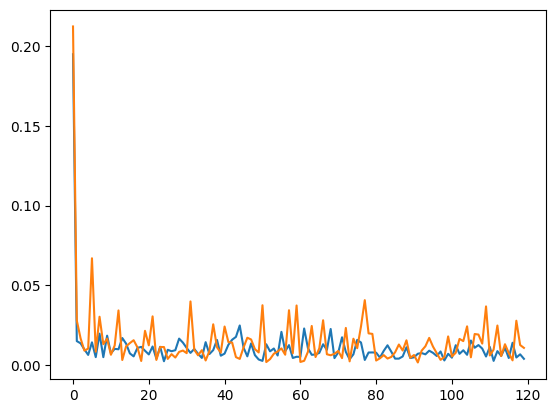

In [ ]:
fig, ax = plt.subplots()
ax.plot(fpga_train['Train_loss'])
ax.plot(fpga_train['Val_loss'])
plt.show()

Test Results

In [ ]:
fpga_test = pd.read_csv('history/nasbench201/fpga_test_results.csv')
fpga_test['Predicted Accuracy'] = [float(x.strip('[]')) for x in fpga_test['Predicted Accuracy']]
fpga_test['Predicted Latency'] = [float(x.strip('[]')) for x in fpga_test['Predicted Latency']]
fpga_test.head()

,Batch,Original Text,True Accuracy,True Latency,Predicted Accuracy,Predicted Latency
0,0,"|1_Convolution:(num_filters=16, kernel_size=3)...",22.733333,1.52960,24.168535,1.362847
1,1,"|1_Convolution:(num_filters=16, kernel_size=3)...",19.366667,1.05872,20.163221,0.974601
2,2,"|1_Convolution:(num_filters=16, kernel_size=3)...",22.266667,1.97120,24.931738,1.733163
3,3,"|1_Convolution:(num_filters=16, kernel_size=3)...",16.033333,0.82512,15.967291,0.697365
4,4,"|1_Convolution:(num_filters=16, kernel_size=3)...",22.600000,1.18992,23.100180,1.022773


Accuracy

0.6513398158445189
0.4638691368406776 0.0


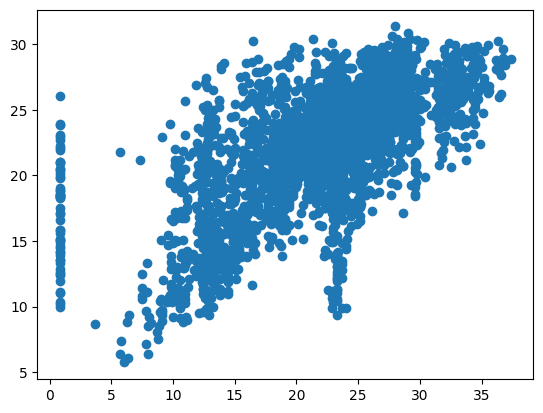

In [ ]:
correlation = np.corrcoef(fpga_test['True Accuracy'], fpga_test['Predicted Accuracy'])[0, 1]
print(correlation)
tau, p_value = kendalltau(fpga_test['True Accuracy'], fpga_test['Predicted Accuracy'])
print(tau, p_value)


fig, ax = plt.subplots()
ax.scatter(fpga_test['True Accuracy'], fpga_test['Predicted Accuracy'])
plt.show()

Latency

Latency Pearson: 0.9938170325600623
Latency Kendall Tau: 0.9249448350948619
0.28432 3.0144
0.18945695 2.558642


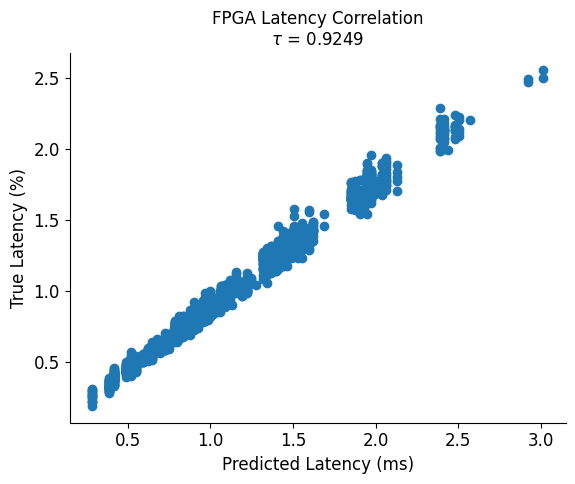

In [ ]:
correlation = np.corrcoef(fpga_test['True Latency'], fpga_test['Predicted Latency'])[0, 1]
print(f'Latency Pearson: {correlation}')
tau, p_value = kendalltau(fpga_test['True Latency'], fpga_test['Predicted Latency'])
print(f'Latency Kendall Tau: {tau}')

print(fpga_test['True Latency'].min(), fpga_test['True Latency'].max())
print(fpga_test['Predicted Latency'].min(), fpga_test['Predicted Latency'].max())

fig, ax = plt.subplots()
ax.scatter(fpga_test['True Latency'], fpga_test['Predicted Latency'])
ax.set_title(f'FPGA Latency Correlation\n$\\tau$ = {tau:.4f}', fontsize=FONT_SIZE)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_ylabel('True Latency (%)', fontsize=FONT_SIZE)
ax.set_xlabel('Predicted Latency (ms)', fontsize=FONT_SIZE)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

Accuracy vs Latency

Latency Pearson: 0.5209102634343148
Latency Kendall Tau: 0.4074530089628681


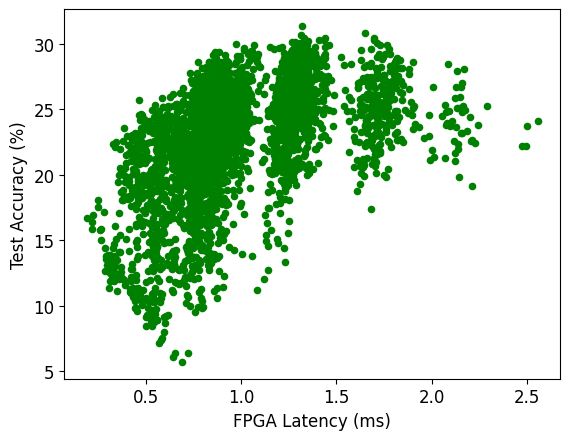

In [ ]:
pareto_indices, pareto_front = pareto_optimality(fpga_test['Predicted Latency'], fpga_test['Predicted Accuracy'])
correlation = np.corrcoef(fpga_test['Predicted Latency'], fpga_test['Predicted Accuracy'])[0, 1]
print(f'Latency Pearson: {correlation}')
tau, p_value = kendalltau(fpga_test['Predicted Latency'], fpga_test['Predicted Accuracy'])
print(f'Latency Kendall Tau: {tau}')

fig, ax = plt.subplots()
ax.scatter(fpga_test['Predicted Latency'], fpga_test['Predicted Accuracy'], s=20, c='green')
ax.set_ylabel('Test Accuracy (%)', fontsize=FONT_SIZE)
ax.set_xlabel('FPGA Latency (ms)', fontsize=FONT_SIZE)
ax.tick_params(axis='both', which='major', labelsize=12)
plt.show()

# Pixel 3

Training Pattern

In [ ]:
pixel3_train = pd.read_csv('history/nasbench201/pixel3_train_history.csv')

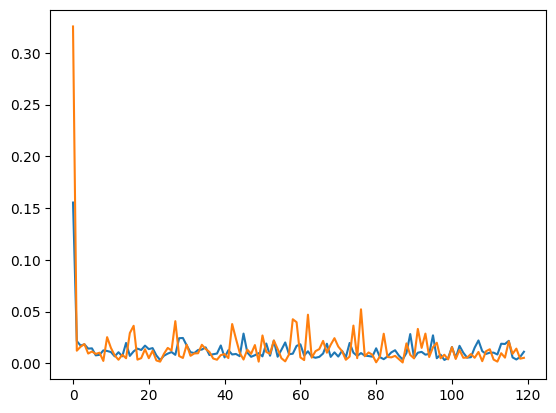

In [ ]:
fig, ax = plt.subplots()
ax.plot(pixel3_train['Train_loss'])
ax.plot(pixel3_train['Val_loss'])
plt.show()

Test Results

In [ ]:
pixel3_test = pd.read_csv('history/nasbench201/pixel3_test_results.csv')
pixel3_test['Predicted Accuracy'] = [float(x.strip('[]')) for x in pixel3_test['Predicted Accuracy']]
pixel3_test['Predicted Latency'] = [float(x.strip('[]')) for x in pixel3_test['Predicted Latency']]
pixel3_test.head()

,Batch,Original Text,True Accuracy,True Latency,Predicted Accuracy,Predicted Latency
0,0,"|1_Convolution:(num_filters=16, kernel_size=3)...",22.733333,1.26387,24.625616,2.840129
1,1,"|1_Convolution:(num_filters=16, kernel_size=3)...",19.366667,4.50507,20.714066,4.587466
2,2,"|1_Convolution:(num_filters=16, kernel_size=3)...",22.266667,8.06677,21.893610,7.203762
3,3,"|1_Convolution:(num_filters=16, kernel_size=3)...",16.033333,2.27623,15.250440,2.812488
4,4,"|1_Convolution:(num_filters=16, kernel_size=3)...",22.600000,4.02210,24.546787,4.421862


Accuracy

0.6556704949504222
0.46787351892234014 0.0


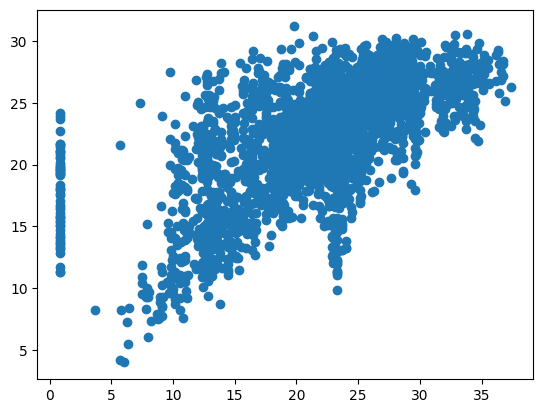

In [ ]:
correlation = np.corrcoef(pixel3_test['True Accuracy'], pixel3_test['Predicted Accuracy'])[0, 1]
print(correlation)
tau, p_value = kendalltau(pixel3_test['True Accuracy'], pixel3_test['Predicted Accuracy'])
print(tau, p_value)


fig, ax = plt.subplots()
ax.scatter(pixel3_test['True Accuracy'], pixel3_test['Predicted Accuracy'])
plt.show()

Latency

Latency Pearson: 0.9593476793911635
Latency Kendall Tau: 0.8289614839318651
0.0052894199999999 12.4421
0.06226857 10.778693


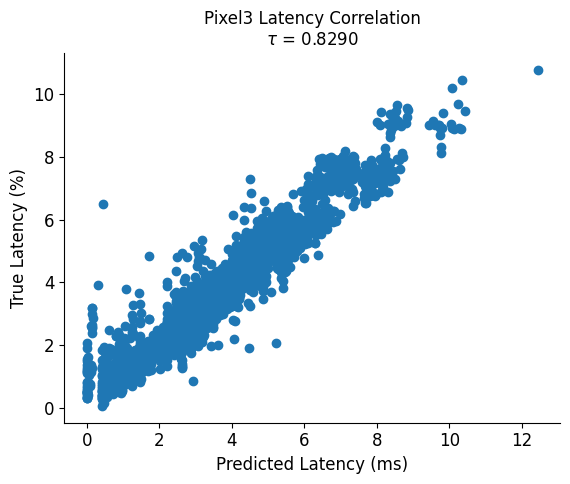

In [ ]:
correlation = np.corrcoef(pixel3_test['True Latency'], pixel3_test['Predicted Latency'])[0, 1]
print(f'Latency Pearson: {correlation}')
tau, p_value = kendalltau(pixel3_test['True Latency'], pixel3_test['Predicted Latency'])
print(f'Latency Kendall Tau: {tau}')

print(pixel3_test['True Latency'].min(), pixel3_test['True Latency'].max())
print(pixel3_test['Predicted Latency'].min(), pixel3_test['Predicted Latency'].max())

fig, ax = plt.subplots()
ax.scatter(pixel3_test['True Latency'], pixel3_test['Predicted Latency'])
ax.set_title(f'Pixel3 Latency Correlation\n$\\tau$ = {tau:.4f}', fontsize=FONT_SIZE)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_ylabel('True Latency (%)', fontsize=FONT_SIZE)
ax.set_xlabel('Predicted Latency (ms)', fontsize=FONT_SIZE)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

Accuracy vs Latency

Latency Pearson: 0.44273416653876985
Latency Kendall Tau: 0.30745813060179256


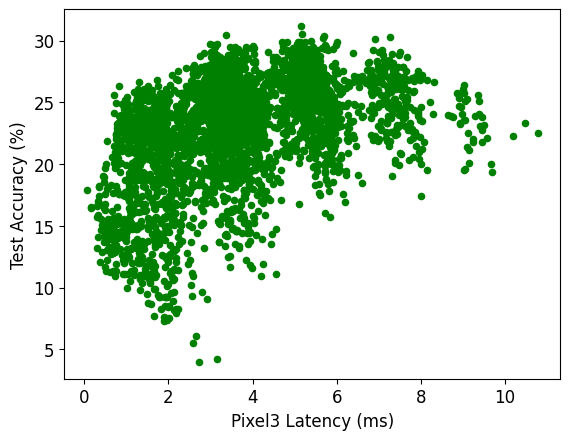

In [ ]:
pareto_indices, pareto_front = pareto_optimality(pixel3_test['Predicted Latency'], pixel3_test['Predicted Accuracy'])
correlation = np.corrcoef(pixel3_test['Predicted Latency'], pixel3_test['Predicted Accuracy'])[0, 1]
print(f'Latency Pearson: {correlation}')
tau, p_value = kendalltau(pixel3_test['Predicted Latency'], pixel3_test['Predicted Accuracy'])
print(f'Latency Kendall Tau: {tau}')

fig, ax = plt.subplots()
ax.scatter(pixel3_test['Predicted Latency'], pixel3_test['Predicted Accuracy'], s=20, c='green')
ax.set_ylabel('Test Accuracy (%)', fontsize=FONT_SIZE)
ax.set_xlabel('Pixel3 Latency (ms)', fontsize=FONT_SIZE)
ax.tick_params(axis='both', which='major', labelsize=12)
plt.show()

# Raspi 4 Output

Training Pattern

In [ ]:
raspi4_train = pd.read_csv('history/nasbench201/raspi4_train_history.csv')

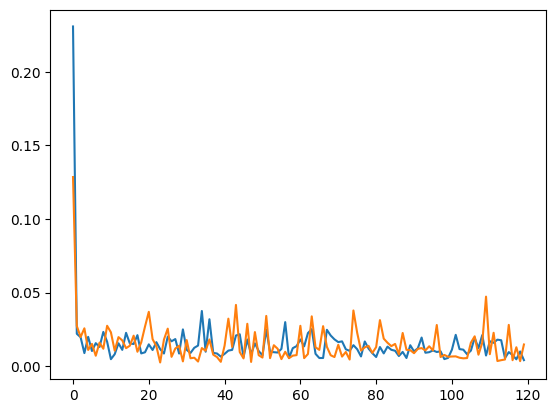

In [ ]:
fig, ax = plt.subplots()
ax.plot(raspi4_train['Train_loss'])
ax.plot(raspi4_train['Val_loss'])
plt.show()

Test Results

In [ ]:
raspi4_test = pd.read_csv('history/nasbench201/raspi4_test_results.csv')
raspi4_test['Predicted Accuracy'] = [float(x.strip('[]')) for x in raspi4_test['Predicted Accuracy']]
raspi4_test['Predicted Latency'] = [float(x.strip('[]')) for x in raspi4_test['Predicted Latency']]
raspi4_test.head()

,Batch,Original Text,True Accuracy,True Latency,Predicted Accuracy,Predicted Latency
0,0,"|1_Convolution:(num_filters=16, kernel_size=3)...",22.733333,3.796125,19.570116,4.892016
1,1,"|1_Convolution:(num_filters=16, kernel_size=3)...",19.366667,6.427056,18.183294,6.784460
2,2,"|1_Convolution:(num_filters=16, kernel_size=3)...",22.266667,11.910316,21.658080,9.184081
3,3,"|1_Convolution:(num_filters=16, kernel_size=3)...",16.033333,4.200611,15.071909,4.243116
4,4,"|1_Convolution:(num_filters=16, kernel_size=3)...",22.600000,7.098667,25.146084,8.013101


Accuracy

0.6518797537587806
0.45821094905793947 0.0


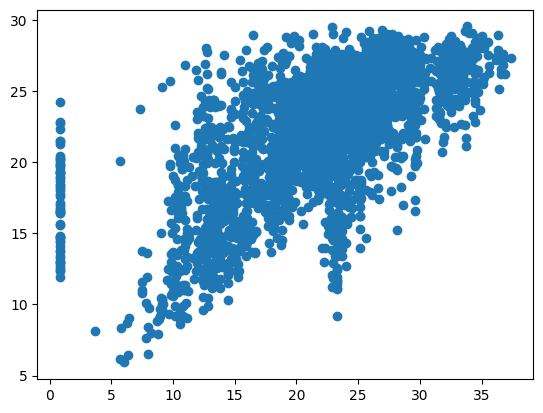

In [ ]:
correlation = np.corrcoef(raspi4_test['True Accuracy'], raspi4_test['Predicted Accuracy'])[0, 1]
print(correlation)
tau, p_value = kendalltau(raspi4_test['True Accuracy'], raspi4_test['Predicted Accuracy'])
print(tau, p_value)


fig, ax = plt.subplots()
ax.scatter(raspi4_test['True Accuracy'], raspi4_test['Predicted Accuracy'])

plt.show()

Latency

Latency Pearson: 0.8972401187267461
Latency Kendall Tau: 0.7473761843790012


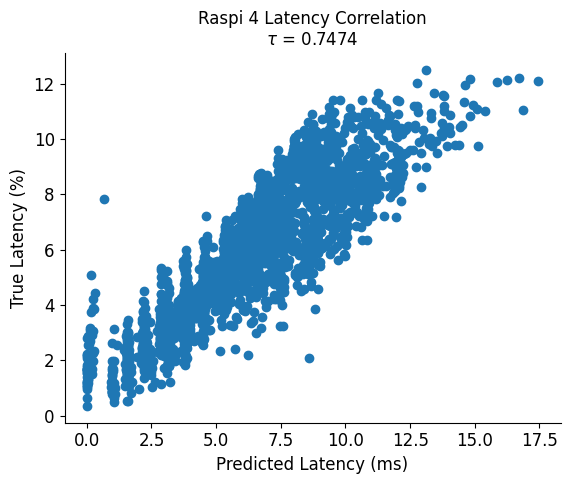

In [ ]:
correlation = np.corrcoef(raspi4_test['True Latency'], raspi4_test['Predicted Latency'])[0, 1]
print(f'Latency Pearson: {correlation}')
tau, p_value = kendalltau(raspi4_test['True Latency'], raspi4_test['Predicted Latency'])
print(f'Latency Kendall Tau: {tau}')

fig, ax = plt.subplots()
ax.scatter(raspi4_test['True Latency'], raspi4_test['Predicted Latency'])
ax.set_title(f'Raspi 4 Latency Correlation\n$\\tau$ = {tau:.4f}', fontsize=FONT_SIZE)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_ylabel('True Latency (%)', fontsize=FONT_SIZE)
ax.set_xlabel('Predicted Latency (ms)', fontsize=FONT_SIZE)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

Accuracy vs Latency

Latency Pearson: 0.5022915412190234
Latency Kendall Tau: 0.35208030729833545


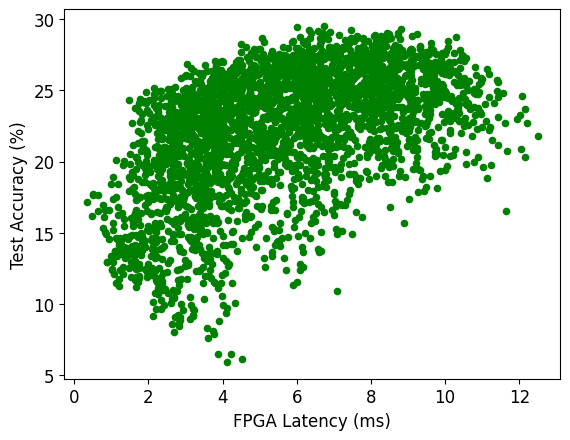

In [ ]:
pareto_indices, pareto_front = pareto_optimality(raspi4_test['Predicted Latency'], raspi4_test['Predicted Accuracy'])
correlation = np.corrcoef(raspi4_test['Predicted Latency'], raspi4_test['Predicted Accuracy'])[0, 1]
print(f'Latency Pearson: {correlation}')
tau, p_value = kendalltau(raspi4_test['Predicted Latency'], raspi4_test['Predicted Accuracy'])
print(f'Latency Kendall Tau: {tau}')

fig, ax = plt.subplots()
ax.scatter(raspi4_test['Predicted Latency'], raspi4_test['Predicted Accuracy'], s=20, c='green')
ax.set_ylabel('Test Accuracy (%)', fontsize=FONT_SIZE)
ax.set_xlabel('FPGA Latency (ms)', fontsize=FONT_SIZE)
ax.tick_params(axis='both', which='major', labelsize=12)
plt.show()